# Preprocesamiento de Datos

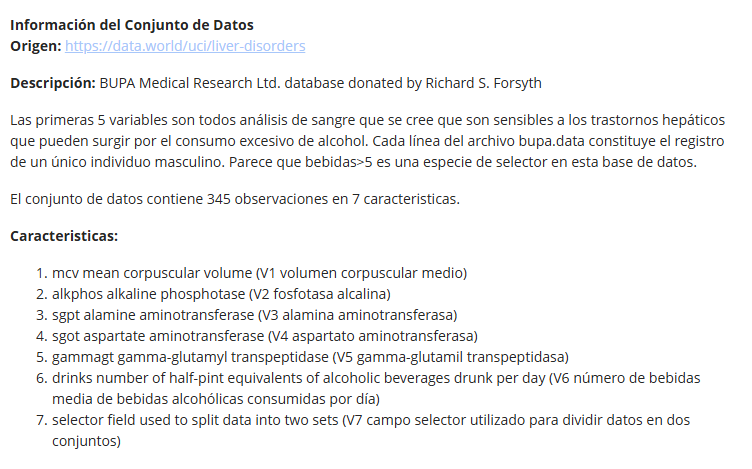

Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

In [3]:
import sys

if 'google.colab' in sys.modules:
    data = pd.read_csv(f'https://raw.githubusercontent.com/dReposU/ML/main/Sem_2/bupa.csv', sep=';')
else:
    data = pd.read_csv("bupa.csv", sep=';')

In [4]:
data.head()

,V1,V2,V3,V4,V5,V6,V7
0,85,92,45,27,31,0.0,1
1,85,64,59,32,23,0.0,2
2,86,54,33,16,54,0.0,2
3,91,78,34,24,36,0.0,2
4,87,70,12,28,10,0.0,2


In [28]:
data.dtypes

,0
V1,int64
V2,int64
V3,int64
V4,int64
V5,int64
V6,float64
V7,int64


In [29]:
data_X = pd.DataFrame(data.drop("V7", axis=1))
data_X.head()

,V1,V2,V3,V4,V5,V6
0,85,92,45,27,31,0.0
1,85,64,59,32,23,0.0
2,86,54,33,16,54,0.0
3,91,78,34,24,36,0.0
4,87,70,12,28,10,0.0


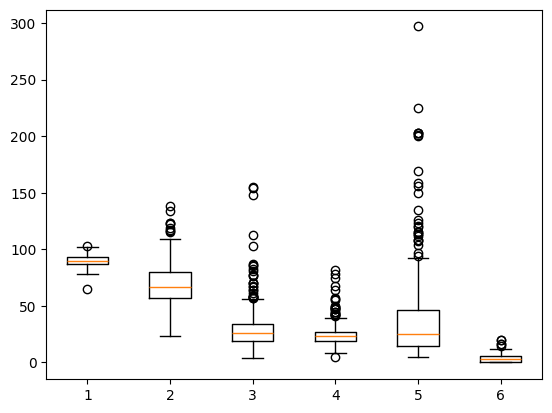

In [30]:
plt.boxplot(data_X)
plt.show()

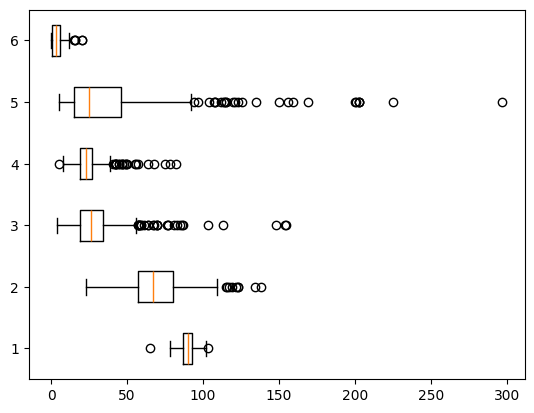

In [31]:
plt.boxplot(data_X, orientation="horizontal")
plt.show()

**Test de Normalidad de Shapiro-Wilk**

- Estadistico W: Que tan parecida es tu distribucion a una normal
- 0.99: Muy cercano a una normal
- 0.95: Bastabte cercano
- 0.90: Algo parecido
- < 0.90 Probablmente no normal
- p-value: Indica si puede asumir normalidad

In [32]:
# Prueba de Normalidad para Variable V1
stats.shapiro(data_X.V1)

ShapiroResult(statistic=np.float64(0.9721210720214322), pvalue=np.float64(3.3408291692175986e-06))

In [33]:
# Prueba de Normalidad para Variable V2
stats.shapiro(data_X.V2)

ShapiroResult(statistic=np.float64(0.9662434242707602), pvalue=np.float64(3.6045510771686095e-07))

In [34]:
# Prueba de Normalidad para Variable V3
stats.shapiro(data_X.V3)

ShapiroResult(statistic=np.float64(0.7289102992482928), pvalue=np.float64(2.5798791941871481e-23))

In [35]:
# Prueba de Normalidad para Variable V4
stats.shapiro(data_X.V4)

ShapiroResult(statistic=np.float64(0.8149622094153431), pvalue=np.float64(1.4028839075597481e-19))

In [36]:
# Prueba de Normalidad para Variable V5
stats.shapiro(data_X.V5)

ShapiroResult(statistic=np.float64(0.6839380588671681), pvalue=np.float64(6.48073466081761e-25))

In [37]:
# Prueba de Normalidad para Variable V6
stats.shapiro(data_X.V6)

ShapiroResult(statistic=np.float64(0.8354936513596574), pvalue=np.float64(1.6864816314857383e-18))

**Regla de los 3 Sigmas**

- Mu: Media
- Sigma: Varianza

- Limite Inferior: Mu - 3*Sigma
- Limite Superior: Mu + 3*Sigma

In [38]:
print("Mas alto permitido: ", data_X["V1"].mean() + 3*data_X["V1"].std())

Mas alto pormitido:  103.50370821474814


In [39]:
print("Mas bajo permitido: ", data_X["V1"].mean() - 3*data_X["V1"].std())

Mas bajo permitido:  76.81513236496201


In [40]:
upper_limit = data_X["V1"].mean() + 3*data_X["V1"].std()
lower_limit = data_X["V1"].mean() - 3*data_X["V1"].std()

In [42]:
data_X[(data_X["V1"] > upper_limit) | (data_X["V1"] < lower_limit)]

,V1,V2,V3,V4,V5,V6
223,65,63,19,20,14,0.5


In [44]:
data_X.shape

(345, 6)

/tmp/ipykernel_9523/201145641.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_X["V1"], orientation="horizontal", palette="Set2")


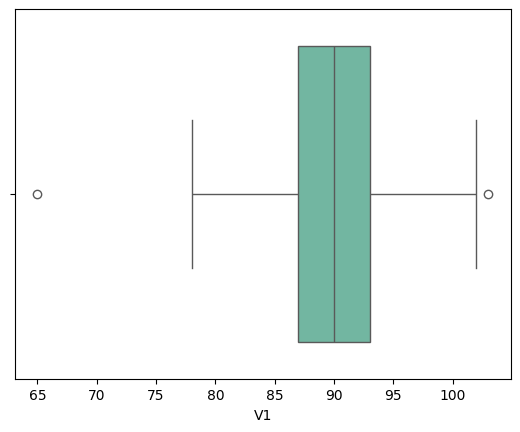

In [48]:
# raficamos
sns.boxplot(x=data_X["V1"], orientation="horizontal", palette="Set2")
plt.show()

In [50]:
new_df_cap = data_X.copy()
new_df_cap["V1"] = np.where(
    new_df_cap["V1"] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap["V1"] < lower_limit,
        lower_limit,
        new_df_cap["V1"]
    )
)

In [51]:
new_df_cap[(new_df_cap["V1"] > upper_limit) | (new_df_cap["V1"] < lower_limit)]

,V1,V2,V3,V4,V5,V6


In [52]:
new_df_cap.shape

(345, 6)

<Axes: ylabel='V1'>

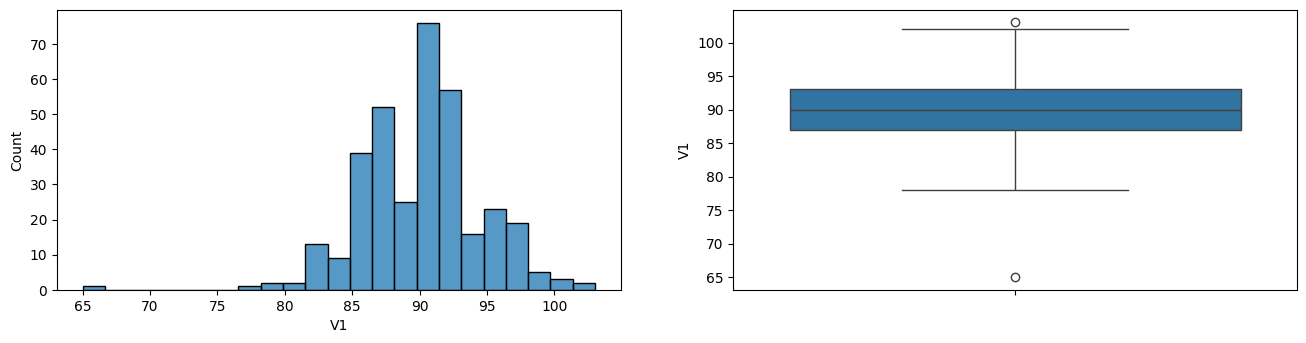

In [53]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(data_X["V1"])
plt.subplot(2,2,2)
sns.boxplot(data_X["V1"])

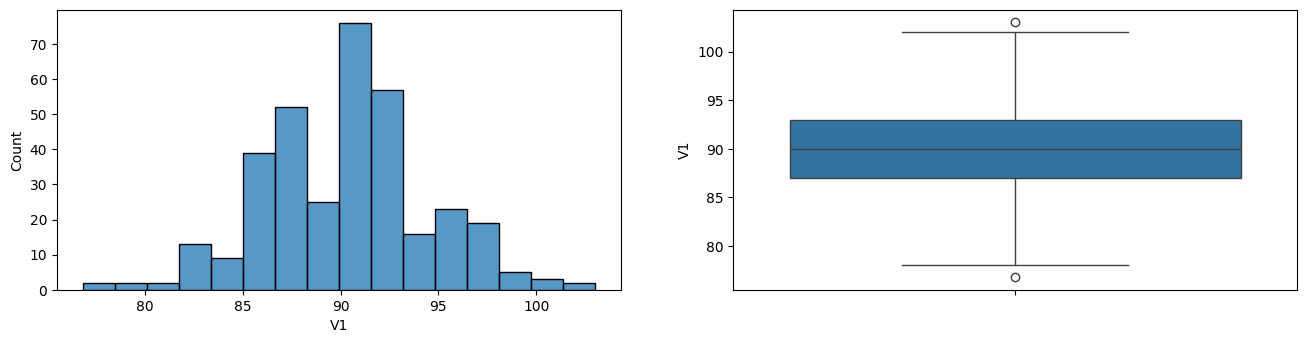

In [54]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,3)
sns.histplot(new_df_cap["V1"])
plt.subplot(2,2,4)
sns.boxplot(new_df_cap["V1"])
plt.show()

**Tratamiento 2:**

In [57]:
data_X = pd.DataFrame(data.drop("V7", axis=1))
data_X.head()

,V1,V2,V3,V4,V5,V6
0,85,92,45,27,31,0.0
1,85,64,59,32,23,0.0
2,86,54,33,16,54,0.0
3,91,78,34,24,36,0.0
4,87,70,12,28,10,0.0


In [58]:
percentile25 = data_X["V1"].quantile(0.25) # Q1
percentile75 = data_X["V1"].quantile(0.75) # Q3
ric = percentile75 - percentile25

In [59]:
upper_limit = percentile75 + 1.5*ric
lower_limit = percentile25 - 1.5*ric

In [61]:
data_X[(data_X["V1"] > upper_limit) | (data_X["V1"] < lower_limit)]

,V1,V2,V3,V4,V5,V6
68,103,75,19,30,13,1.0
223,65,63,19,20,14,0.5


In [65]:
# Suavizado de Datos

new_df_cap = data_X.copy()
new_df_cap["V1"] = np.where(
    new_df_cap["V1"] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap["V1"] < lower_limit,
        lower_limit,
        new_df_cap["V1"]
    )
)

In [66]:
new_df_cap[(new_df_cap["V1"] > upper_limit) | (new_df_cap["V1"] < lower_limit)]

,V1,V2,V3,V4,V5,V6


<Axes: ylabel='V1'>

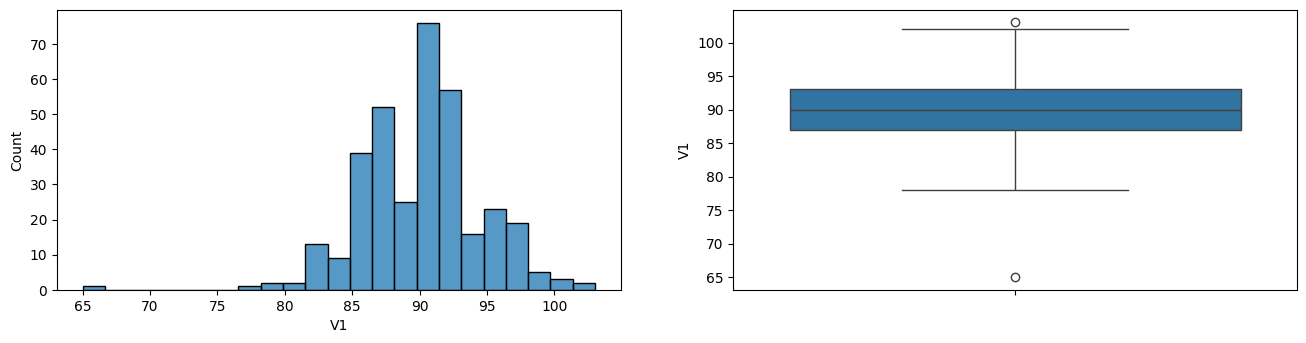

In [67]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(data_X["V1"])
plt.subplot(2,2,2)
sns.boxplot(data_X["V1"])

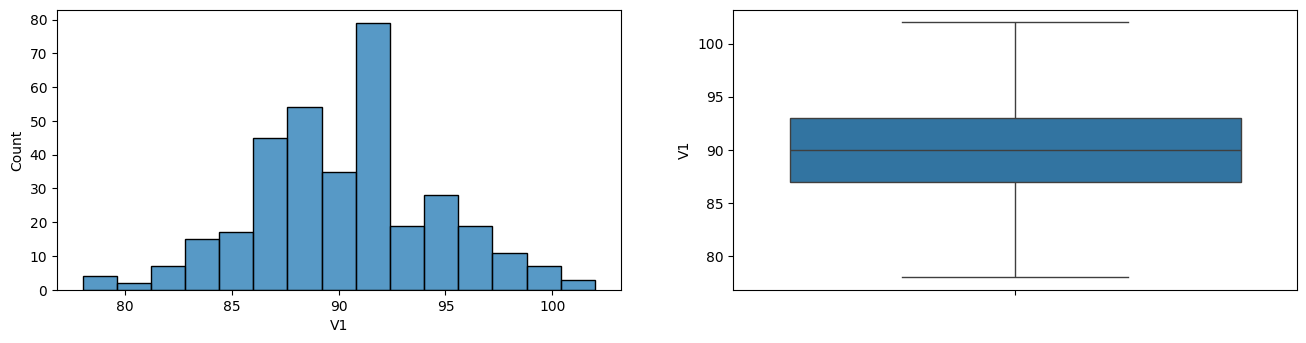

In [68]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,3)
sns.histplot(new_df_cap["V1"])
plt.subplot(2,2,4)
sns.boxplot(new_df_cap["V1"])
plt.show()